Завдання 1. Ми обговорили з Вами на лекції, що велика літера Сігма грецького алфавіту позначає в математиці суму. Знайдіть з використанням Python Σx, Σx2, та Σ(x−1)2 для наступного набору даних: 1 3 4 Виведіть результат кожного обчислення на екран.

In [1]:
import numpy as np
import pandas as pd

In [3]:
x=np.array([1,3,4])
sigma1=sum(x)
sigma2=sum(x**2)
sigma3=sum((x-1)**2)
print (sigma1,sigma2,sigma3)

8 26 13


Завдання 2. Ми зібрали дані про суму покупок в гривнях 20ма випадково обраними клієнтами в нашому магазині (всього клієнтів у нас більше) за минулий місяць. Вони представлені в змінній sum_purchases. Знайдіть вибіркове середнє для цих даних кожним з зазначених методів:

2.1. без використання жодних бібліотек, користуючись тільки Python.
2.2. використовуючи відповідний метод бібліотеки numpy.

Виведіть результат обчислень в кожному з випадків на екран та порівняйте результати. Вони співпадають?

In [4]:
sum_purchases = [ 316,  493,  367,  153,  224,  121,  322,  450,  196,  397,  281,
  239,  484,  124,  223,  448,  432,  255, 4310, 3524]
x=sum_purchases
x_mean=sum(x)/len(x)
x_mean_np=np.mean(x)
print(x_mean)
print(x_mean_np)

667.95
667.95


Завдання 3. Для того ж набору даних в змінній sum_purchases обчисліть медіану кожним з зазначених методів:

3.1. без використання жодних бібліотек, користуючись тільки Python.
3.2. використовуючи відповідний метод бібліотеки numpy.

Виведіть результат обчислень в кожному з випадків на екран. Порівняйте результати зі значенням вибіркового середнього. Напишіть коментар, для яких задач ви б використовували вибіркове середнє, а для яких - медіану?

In [5]:
x_s=sorted(x)
x_median=(x_s[len(x)//2-1]+x_s[len(x)//2])/2
print(x_median)
x_median_np=np.median(x_s)
print(x_median_np)

319.0
319.0


Вибіркове середнє краще використовувати, коли немає аномальних даних у вибірці, які вирізняються з основної маси. Медіану навпаки, коли є аномальні показники у вибірці.

Завдання 4. Обчислість стандартне відхилення наведеної вибірки в змінній sum_purchases кожним з зазначених методів:

4.1. без використання жодних бібліотек, користуючись тільки Python.
4.2. використовуючи відповідний метод бібліотеки numpy.

Виведіть результат обчислень в кожному з випадків на екран.

In [6]:
x_minus_mean=[(el-x_mean)**2 for el in x]
std_x_sample=np.sqrt(sum(x_minus_mean)/(len(x)-1))
print(std_x_sample)
np.std(x, ddof=1)
std_x=np.std(x, ddof=1)
print(std_x)

1124.5433447451132
1124.5433447451132


Завдання 5. Ми провели дослідження віку студентів-першокурсників. Виявилось, що

10 студентів мають вік 16 років
25 студентів - 17 років
20 студентів - 18 років
2 студенти - 20 років
Обчислість середнє значення для цієї вибірки будь-яким способом - на чистому Python або з numpy - та виведіть результат на екран.

In [7]:
ages=[16,17,18,20]
counts=[10,25,20,2]
x=np.repeat(ages, counts)
np.mean(x)

np.float64(17.280701754385966)

Завдання 6. Крім даних про суму покупок, ми зібрали ще дані про кількість відвідувань кожного з кожного покупця, які знаходяться в змінній visits. Обчисліть коефіцієнт кореляції Пірсона для суми покупок і кількості відвідувань кожним з зазначених методів:

6.1. без використання жодних бібліотек, користуючись тільки Python.
6.2. використовуючи відповідний метод бібліотеки numpy.

Виведіть результат на екран. Проаналізуйте результат.

Виведіть додатково графік розсіювання викликавши код нижче і зробіть заключення, чи варто щось змінити при підрахунку кореляції, аби коефіцієнт Пірсона показував коректну оцінку лінійної залежності?

In [21]:
visits=[6, 2, 10, 3, 9, 9, 2, 3, 6, 6, 10, 2, 5, 10, 3, 5, 4, 7, 4, 2]
y=visits
y_mean=sum(visits)/len(visits)
y_minus_mean=[(el-y_mean)**2 for el in y]
std_y_sample=np.sqrt(sum(y_minus_mean) / (len(y) - 1))

n=sum((sp-x_mean)*(v-y_mean)for sp, v  in zip(sum_purchases, visits))
r=n/((len(visits)-1)*std_x_sample*std_y_sample)
print(r)
np.corrcoef(sum_purchases, visits)


-0.30265844687666454


array([[ 1.        , -0.30265845],
       [-0.30265845,  1.        ]])

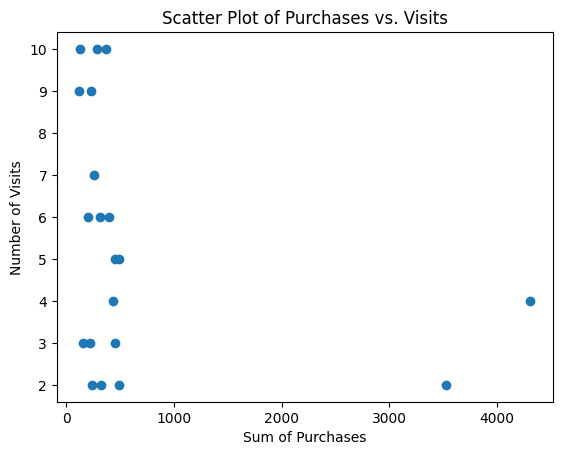

In [13]:
import matplotlib.pyplot as plt

plt.scatter(sum_purchases, visits)
plt.title('Scatter Plot of Purchases vs. Visits')
plt.xlabel('Sum of Purchases')
plt.ylabel('Number of Visits');

Треба виключити з вібирка 2 викиди, які псують картину.

Завдання 7. В попередньому завданні ми помітили, що викиди нам заважають отримати "правдиве" значення кореляції. Давайте вилучимо записи, які відповідають значенням з викидами в сумі покупок і обчисліть коеф. кореляції. Для цього поставте threshold, який дорінює середньому значенню + 2 стандартних вдіхилля суми покупок і всі значення, які більше за нього, будемо вважати викидами (є і інші правила для визначення викидів - з ним и познайомимось пізніше).

Вилучіть значення з обох масивів і обчисліть коеф. кореляції Пірсона з допомогою numpy для кількості візитів і суми покупок без записів-викидів. Виведіть результат на екран, побудуйте діаграму розсіювання і проаналізуйте результат: що можемо сказати про залежність в даних?

In [25]:
threshold=np.mean(sum_purchases)+2*np.std(sum_purchases)
filtered_purchases, filtered_visits = zip(*[(sp, v) for sp, v in zip(sum_purchases, visits) if sp <= threshold])
r_clean = np.corrcoef(filtered_purchases, filtered_visits)[0, 1]
print(f"Видалено записів: {len(sum_purchases) - len(filtered_purchases)}")
print(f"Кореляція без викидів: {r_clean:.4f}")

Видалено записів: 2
Кореляція без викидів: -0.3685


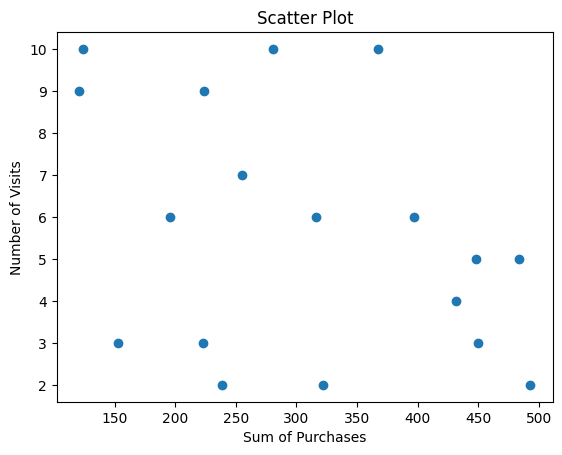

In [27]:
plt.scatter(filtered_purchases, filtered_visits)
plt.title('Scatter Plot')
plt.xlabel('Sum of Purchases')
plt.ylabel('Number of Visits')
plt.show()